# Problem 3 — Audio entropy: ambient noise vs. music


## Method

$$
\widehat H_Q = -\sum_b \widehat p_b \log_2 \widehat p_b
$$

$$
\widehat H = \widehat H_Q + \log_2 \Delta
$$

$$
H_{\max} = \log_2 K
$$

$$
H_{\text{Gauss}} = \tfrac12 \log_2(2\pi e\widehat\sigma^2)
$$

$$
\text{gap} = H_{\text{Gauss}} - \widehat H
$$


In [38]:
# Imports and shared analysis constants.
import os
import glob
import wave
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use only the processed WAV dataset for Problem 3.
DATA_DIR = os.path.abspath(os.path.join("..", "..", "Data", "q3", "processed"))
assert os.path.isdir(DATA_DIR), f"Processed data dir not found: {DATA_DIR}"
print("Reading WAV files from:", DATA_DIR)

# Common histogram bin width and expected audio sampling rate.
DELTA = 0.005
TARGET_SR = 16000
RNG = np.random.default_rng(4010)


Reading WAV files from: /Users/dinhieufam/DINHHIEU/VINUNI/Spring 26/MATH4010 - Advanced Probility and Statistics/COMP4010--Advanced-Prob-Stat----Final-Project/Data/q3/processed


In [39]:
def load_wav_mono(path):
    """Load a mono 16-bit PCM WAV file as float64 in [-1, 1)."""
    # Read WAV metadata and raw PCM bytes.
    with wave.open(path, "rb") as w:
        sr = w.getframerate()
        nch = w.getnchannels()
        sw = w.getsampwidth()
        nframes = w.getnframes()
        raw = w.readframes(nframes)

    # Convert int16 PCM to floating-point samples.
    assert sw == 2, f"{path}: expected 16-bit PCM, got sample width {sw}"
    x = np.frombuffer(raw, dtype=np.int16).astype(np.float64)

    # Downmix stereo or multi-channel audio if needed.
    if nch > 1:
        x = x.reshape(-1, nch).mean(axis=1)
    return sr, x / 32768.0


def peak_normalize(x):
    """Scale one clip to max |x| = 1, preserving silence if present."""
    peak = float(np.max(np.abs(x)))
    return x if peak == 0 else x / peak


def entropy_quantities(x, delta):
    """Return entropy quantities in bits using bin width `delta`."""
    # Build a common-width histogram over the peak-normalized sample range.
    lo, hi = float(np.min(x)), float(np.max(x))
    K = max(2, int(np.ceil((1 - (-1)) / delta)))
    edges = lo + delta * np.arange(K + 1)
    edges[-1] = max(edges[-1], hi + np.finfo(float).eps)

    # Estimate the empirical probability mass in each occupied bin.
    counts, _ = np.histogram(x, bins=edges)
    p = counts.astype(np.float64) / counts.sum()
    nz = p > 0

    # Compute discrete entropy, differential entropy estimate, and Gaussian reference.
    H_Q = float(-np.sum(p[nz] * np.log2(p[nz])))
    H_diff = float(H_Q + np.log2(delta))
    H_max = float(np.log2(K))
    sigma2 = float(np.var(x))
    H_gauss = float(0.5 * np.log2(2 * np.pi * np.e * sigma2)) if sigma2 > 0 else -np.inf
    return H_Q, H_diff, H_max, H_gauss, K, sigma2


def clip_path(cls, fname):
    """Return the path for one processed clip."""
    return os.path.join(DATA_DIR, cls, fname)


def load_clip(cls, fname, normalized=True):
    """Load a processed clip by class and filename."""
    sr, x = load_wav_mono(clip_path(cls, fname))
    assert sr == TARGET_SR, f"{fname}: sample rate {sr} != {TARGET_SR}"
    return peak_normalize(x) if normalized else x


In [40]:
# Compute one row of entropy statistics per processed clip.
rows = []
for cls in ["music", "noise"]:
    cdir = os.path.join(DATA_DIR, cls)
    assert os.path.isdir(cdir), f"Missing class folder: {cdir}"

    # Process all WAV files in the current class folder.
    for path in sorted(glob.glob(os.path.join(cdir, "*.wav"))):
        fname = os.path.basename(path)
        sr, raw = load_wav_mono(path)
        assert sr == TARGET_SR, f"{fname}: sample rate {sr} != {TARGET_SR}"

        # Peak-normalize before histogram entropy estimation.
        peak = float(np.max(np.abs(raw)))
        x = peak_normalize(raw)
        H_Q, H_diff, H_max, H_gauss, K, sigma2 = entropy_quantities(x, DELTA)

        rows.append({
            "file": fname,
            "class": cls,
            "N": len(x),
            "duration_s": len(x) / sr,
            "peak": peak,
            "sigma2": sigma2,
            "K_bins": K,
            "H_Q": H_Q,
            "H_diff": H_diff,
            "H_max": H_max,
            "H_gauss": H_gauss,
            "gap": H_gauss - H_diff,
        })

# Keep the table in a stable class/file order.
df = pd.DataFrame(rows).sort_values(["class", "file"]).reset_index(drop=True)
assert set(df["class"]) == {"music", "noise"}
assert len(df) == 20, f"Expected 20 processed clips, found {len(df)}"
df.round(4)


,file,class,N,duration_s,peak,sigma2,K_bins,H_Q,H_diff,H_max,H_gauss,gap
0,music_01.wav,music,480000,30.0,0.1855,0.0322,400,7.2106,-0.4333,8.6439,-0.4319,0.0014
1,music_02.wav,music,480000,30.0,0.2588,0.0326,400,7.2206,-0.4233,8.6439,-0.4221,0.0012
2,music_03.wav,music,480000,30.0,0.2529,0.0213,400,6.8962,-0.7476,8.6439,-0.7285,0.0192
3,music_04.wav,music,480000,30.0,0.3104,0.0250,400,7.0247,-0.6192,8.6439,-0.6134,0.0058
4,music_05.wav,music,480000,30.0,0.2270,0.0308,400,7.1799,-0.4640,8.6439,-0.4633,0.0007
5,music_06.wav,music,480000,30.0,0.1837,0.0312,400,7.1866,-0.4573,8.6439,-0.4533,0.0040
6,music_07.wav,music,480000,30.0,0.1860,0.0239,400,6.9950,-0.6489,8.6439,-0.6462,0.0027
7,music_08.wav,music,480000,30.0,0.2108,0.0128,400,6.5374,-1.1065,8.6439,-1.0990,0.0075
8,music_09.wav,music,480000,30.0,0.1656,0.0421,400,7.4046,-0.2392,8.6439,-0.2377,0.0015
9,music_10.wav,music,480000,30.0,0.1855,0.0322,400,7.2106,-0.4333,8.6439,-0.4319,0.0014


## Class summaries


In [41]:
# Summarize entropy quantities by class.
summary = (
    df.groupby("class")[["H_Q", "H_diff", "H_max", "H_gauss", "gap", "sigma2", "duration_s"]]
      .agg(["mean", "std"])
      .round(4)
)
summary


H_Q          H_diff           H_max      H_gauss             gap  \
         mean     std    mean     std    mean  std    mean     std    mean   
class                                                                        
music  7.0866  0.2401 -0.5572  0.2401  8.6439  0.0 -0.5527  0.2369  0.0045   
noise  7.1916  0.4503 -0.4523  0.4503  8.6439  0.0 -0.4477  0.4457  0.0046   

               sigma2         duration_s       
          std    mean     std       mean  std  
class                                          
music  0.0056  0.0284  0.0080       30.0  0.0  
noise  0.0072  0.0361  0.0164       30.0  0.0

In [42]:
# Compare class means directly as music minus noise.
means = df.groupby("class")[["H_Q", "H_diff", "H_gauss", "gap", "sigma2"]].mean()
music_minus_noise = (means.loc["music"] - means.loc["noise"]).round(4)

mean_comparison = pd.DataFrame({
    "music": means.loc["music"],
    "noise": means.loc["noise"],
    "music_minus_noise": means.loc["music"] - means.loc["noise"],
}).round(4)
mean_comparison


Mean differences (music - noise):
H_Q       -0.1049
H_diff    -0.1049
H_gauss   -0.1050
gap       -0.0001
sigma2    -0.0077
dtype: float64

Music mean H_Q:     7.0866 bits/sample
Noise mean H_Q:     7.1916 bits/sample
Music mean gap:     0.0045 bits
Noise mean gap:     0.0046 bits

Music has lower discrete entropy than noise.
Music is not farther from Gaussian than noise under this amplitude-distribution metric.


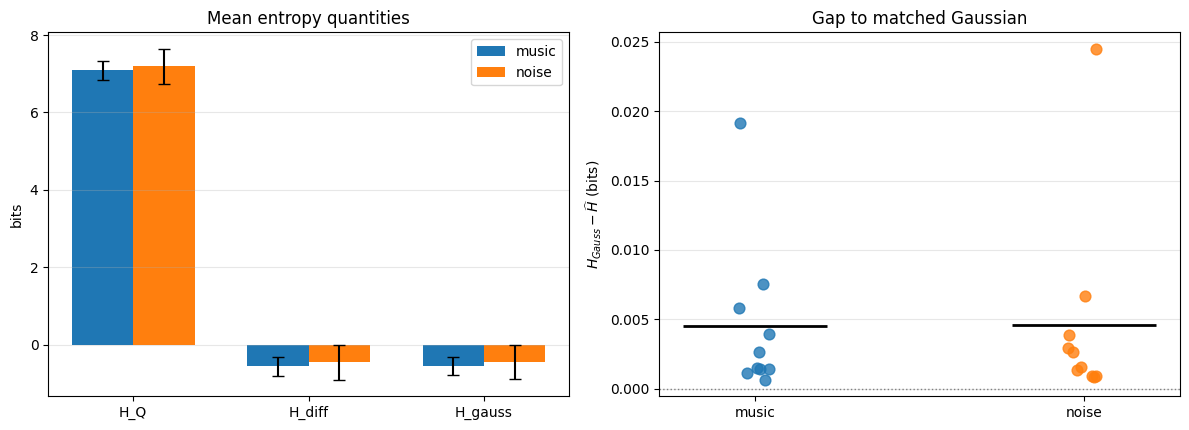

In [43]:
# Plot class-level entropy means and per-clip Gaussian gaps.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# Grouped bar chart for entropy quantities.
ax = axes[0]
metrics = ["H_Q", "H_diff", "H_gauss"]
x = np.arange(len(metrics))
width = 0.35
for offset, cls in [(-width / 2, "music"), (width / 2, "noise")]:
    g = df[df["class"] == cls]
    ax.bar(x + offset, [g[m].mean() for m in metrics], width,
           yerr=[g[m].std() for m in metrics], capsize=4, label=cls)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("bits")
ax.set_title("Mean entropy quantities")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()

# Scatter plot for the Gaussian gap of each clip.
ax = axes[1]
rng = np.random.default_rng(0)
for i, cls in enumerate(["music", "noise"]):
    gaps = df.loc[df["class"] == cls, "gap"].to_numpy()
    jitter = rng.uniform(-0.05, 0.05, size=len(gaps))
    ax.scatter(np.full_like(gaps, i, dtype=float) + jitter, gaps, s=60, alpha=0.8)
    ax.hlines(gaps.mean(), i - 0.22, i + 0.22, colors="black", linewidth=2)
ax.set_xticks([0, 1])
ax.set_xticklabels(["music", "noise"])
ax.set_ylabel(r"$H_{Gauss} - \widehat H$ (bits)")
ax.set_title("Gap to matched Gaussian")
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## Representative amplitude distributions


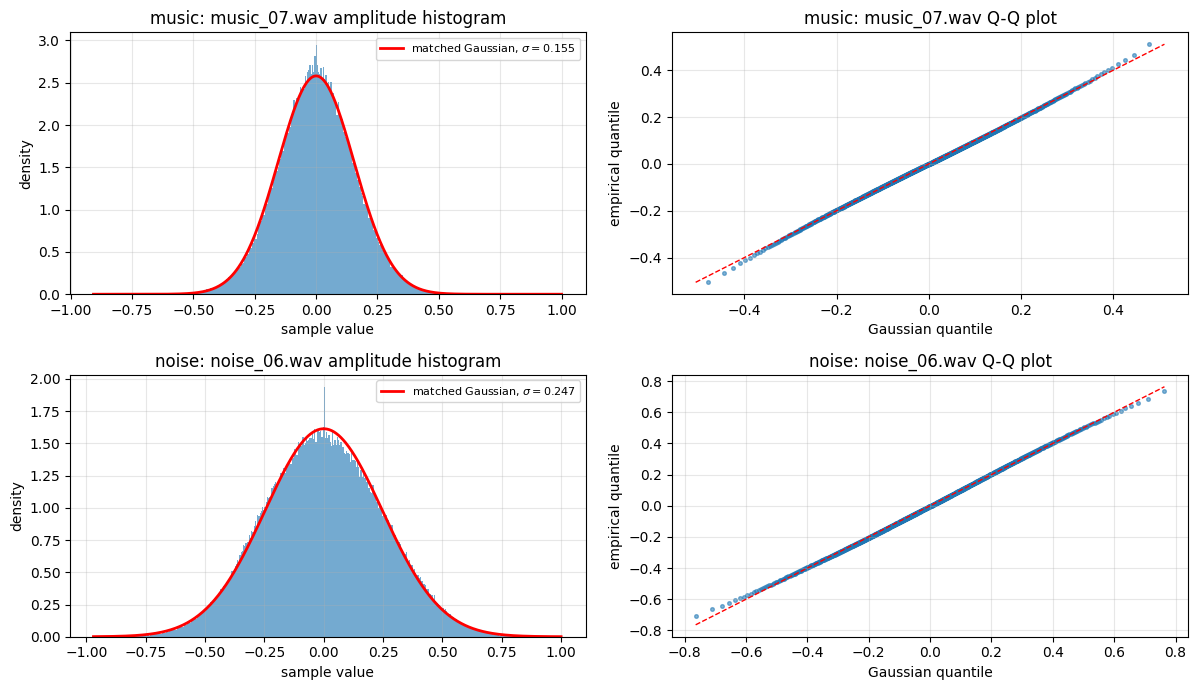

In [44]:
# Use Q-Q plots and histograms for median-gap representative clips.
normal = NormalDist()
qq_probs = np.linspace(0.001, 0.999, 999)

def representative_file(cls):
    """Choose the median-gap clip within one class."""
    g = df[df["class"] == cls].sort_values("gap").reset_index(drop=True)
    return g.iloc[len(g) // 2]["file"]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, cls in enumerate(["music", "noise"]):
    # Load the representative clip and matched Gaussian density.
    fname = representative_file(cls)
    x = load_clip(cls, fname, normalized=True)
    mu = float(np.mean(x))
    sig = float(np.std(x))
    xs = np.linspace(x.min(), x.max(), 600)
    gauss = np.exp(-0.5 * ((xs - mu) / sig) ** 2) / (sig * np.sqrt(2 * np.pi))

    # Histogram against the matched Gaussian curve.
    hist_ax, qq_ax = axes[row]
    hist_ax.hist(x, bins=np.arange(x.min(), x.max() + DELTA, DELTA), density=True, alpha=0.62)
    hist_ax.plot(xs, gauss, "r-", linewidth=2, label=fr"matched Gaussian, $\sigma={sig:.3f}$")
    hist_ax.set_title(f"{cls}: {fname} amplitude histogram")
    hist_ax.set_xlabel("sample value")
    hist_ax.set_ylabel("density")
    hist_ax.grid(True, alpha=0.3)
    hist_ax.legend(fontsize=8)

    # Q-Q plot against the same matched Gaussian reference.
    theoretical = mu + sig * np.array([normal.inv_cdf(float(p)) for p in qq_probs])
    empirical = np.quantile(x, qq_probs)
    lim = [min(theoretical.min(), empirical.min()), max(theoretical.max(), empirical.max())]
    qq_ax.scatter(theoretical, empirical, s=7, alpha=0.55)
    qq_ax.plot(lim, lim, "r--", linewidth=1)
    qq_ax.set_title(f"{cls}: {fname} Q-Q plot")
    qq_ax.set_xlabel("Gaussian quantile")
    qq_ax.set_ylabel("empirical quantile")
    qq_ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Bin-width sensitivity


In [45]:
# Recompute entropy statistics over several histogram bin widths.
deltas = np.array([2.0 ** (-k) for k in range(15, 7, -1)])
sensitivity_rows = []
for delta in deltas:
    for _, row in df.iterrows():
        x = load_clip(row["class"], row["file"], normalized=True)
        H_Q, H_diff, H_max, H_gauss, K, sigma2 = entropy_quantities(x, delta)
        sensitivity_rows.append({
            "delta": delta,
            "file": row["file"],
            "class": row["class"],
            "H_Q": H_Q,
            "H_diff": H_diff,
            "H_gauss": H_gauss,
            "gap": H_gauss - H_diff,
            "K_bins": K,
        })

# Pivot class means for compact comparison across bin widths.
sensitivity_df = pd.DataFrame(sensitivity_rows)
pivot_gap = sensitivity_df.pivot_table(index="delta", columns="class", values="gap", aggfunc="mean")
pivot_gap["music_minus_noise"] = pivot_gap["music"] - pivot_gap["noise"]
pivot_entropy = sensitivity_df.pivot_table(index="delta", columns="class", values="H_Q", aggfunc="mean")
pivot_entropy["music_minus_noise"] = pivot_entropy["music"] - pivot_entropy["noise"]

bin_width_comparison = pd.concat(
    {
        "H_Q": pivot_entropy.round(4),
        "gap": pivot_gap.round(4),
    },
    axis=1,
)
bin_width_comparison


Mean H_Q difference by bin width (music - noise):
delta
0.000031   -0.6137
0.000061   -0.5957
0.000122   -0.2500
0.000244   -0.1275
0.000488   -0.1048
0.000977   -0.1055
0.001953   -0.1051
0.003906   -0.1049
Name: music_minus_noise, dtype: float64

Mean Gaussian-gap difference by bin width (music - noise):
delta
0.000031    0.5086
0.000061    0.4907
0.000122    0.1449
0.000244    0.0225
0.000488   -0.0003
0.000977    0.0004
0.001953    0.0001
0.003906   -0.0001
Name: music_minus_noise, dtype: float64


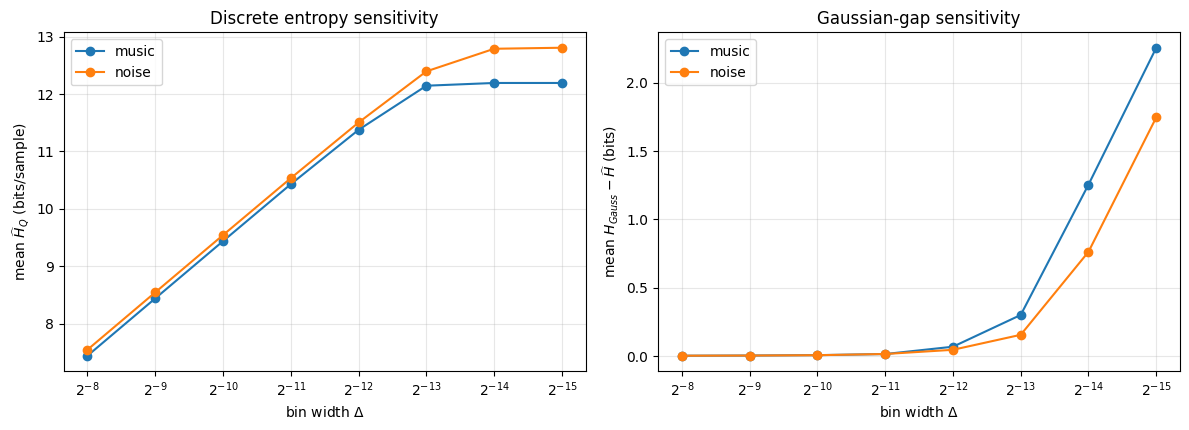

In [46]:
# Plot entropy and Gaussian-gap sensitivity to bin width.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for cls in ["music", "noise"]:
    g = sensitivity_df[sensitivity_df["class"] == cls]
    mean_by_delta = g.groupby("delta")[["H_Q", "gap"]].mean()
    axes[0].plot(mean_by_delta.index, mean_by_delta["H_Q"], marker="o", label=cls)
    axes[1].plot(mean_by_delta.index, mean_by_delta["gap"], marker="o", label=cls)

for ax in axes:
    ax.set_xscale("log", base=2)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r"bin width $\Delta$")
    ax.legend()
axes[0].set_ylabel(r"mean $\widehat H_Q$ (bits/sample)")
axes[0].set_title("Discrete entropy sensitivity")
axes[1].set_ylabel(r"mean $H_{Gauss} - \widehat H$ (bits)")
axes[1].set_title("Gaussian-gap sensitivity")
plt.tight_layout()
plt.show()


## Bootstrap confidence intervals and effect size


In [47]:
def bootstrap_ci(values, statistic=np.mean, n_boot=10000, confidence=0.95, rng=RNG):
    """Bootstrap a confidence interval for one sample statistic."""
    values = np.asarray(values, dtype=float)
    stats = np.empty(n_boot)

    # Resample clips with replacement and evaluate the statistic.
    for b in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        stats[b] = statistic(sample)

    alpha = (1 - confidence) / 2
    return float(np.quantile(stats, alpha)), float(np.quantile(stats, 1 - alpha))

# Bootstrap class-wise mean Gaussian gaps.
bootstrap_rows = []
for cls in ["noise", "music"]:
    values = df.loc[df["class"] == cls, "gap"].to_numpy()
    lo, hi = bootstrap_ci(values)
    bootstrap_rows.append({
        "quantity": f"mean gap ({cls})",
        "estimate": values.mean(),
        "ci_95_low": lo,
        "ci_95_high": hi,
    })

noise_values = df.loc[df["class"] == "noise", "gap"].to_numpy()
music_values = df.loc[df["class"] == "music", "gap"].to_numpy()

def diff_mean_stat(sampled_pairs):
    """Mean-gap difference for a concatenated noise/music bootstrap sample."""
    n = len(noise_values)
    return sampled_pairs[:n].mean() - sampled_pairs[n:].mean()

# Bootstrap each class independently for the noise-minus-music mean gap.
diff_stats = np.empty(10000)
for b in range(len(diff_stats)):
    n_sample = RNG.choice(noise_values, size=len(noise_values), replace=True)
    m_sample = RNG.choice(music_values, size=len(music_values), replace=True)
    diff_stats[b] = n_sample.mean() - m_sample.mean()

# Cohen's d for the class separation in Gaussian gap.
pooled_sd = np.sqrt(((len(noise_values) - 1) * noise_values.var(ddof=1) +
                     (len(music_values) - 1) * music_values.var(ddof=1)) /
                    (len(noise_values) + len(music_values) - 2))
cohens_d = (noise_values.mean() - music_values.mean()) / pooled_sd
bootstrap_rows.append({
    "quantity": "mean gap difference (noise - music)",
    "estimate": noise_values.mean() - music_values.mean(),
    "ci_95_low": float(np.quantile(diff_stats, 0.025)),
    "ci_95_high": float(np.quantile(diff_stats, 0.975)),
})
bootstrap_rows.append({
    "quantity": "Cohen's d for gap (noise vs music)",
    "estimate": cohens_d,
    "ci_95_low": np.nan,
    "ci_95_high": np.nan,
})

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.round(4)


,quantity,estimate,ci_95_low,ci_95_high
0,mean gap (noise),0.0046,0.0016,0.0094
1,mean gap (music),0.0045,0.0019,0.0082
2,mean gap difference (noise - music),0.0001,-0.0052,0.0056
3,Cohen's d for gap (noise vs music),0.0144,NaN,NaN


## Recording-length sensitivity


In [48]:
# Split each processed 30-second clip into non-overlapping windows.
WINDOW_SECONDS = [1, 2, 3, 5, 6, 10, 15, 30]

length_rows = []
for _, row in df.iterrows():
    sr, raw = load_wav_mono(clip_path(row["class"], row["file"]))
    assert sr == TARGET_SR, f"{row['file']}: sample rate {sr} != {TARGET_SR}"

    # Compute entropy statistics for every full window at each duration.
    for length_s in WINDOW_SECONDS:
        window_n = int(length_s * sr)
        n_windows = len(raw) // window_n
        for window_idx in range(n_windows):
            start = window_idx * window_n
            segment = raw[start:start + window_n]
            if np.max(np.abs(segment)) == 0:
                continue

            x = peak_normalize(segment)
            H_Q, H_diff, H_max, H_gauss, K, sigma2 = entropy_quantities(x, DELTA)
            gap = H_gauss - H_diff
            if not np.isfinite(gap):
                continue

            length_rows.append({
                "class": row["class"],
                "file": row["file"],
                "length_s": length_s,
                "window_idx": window_idx,
                "H_Q": H_Q,
                "H_diff": H_diff,
                "H_gauss": H_gauss,
                "gap": gap,
                "sigma2": sigma2,
            })

length_segment_df = pd.DataFrame(length_rows)

# Average windows within each original clip before class-level summaries.
length_clip_df = (
    length_segment_df
    .groupby(["length_s", "class", "file"])[["H_Q", "H_diff", "H_gauss", "gap", "sigma2"]]
    .mean()
    .reset_index()
)

length_summary = (
    length_clip_df
    .groupby(["length_s", "class"])[["H_Q", "H_diff", "H_gauss", "gap"]]
    .agg(["mean", "std", "count"])
    .round(4)
)

# Compare music and noise means at each window length.
length_means = length_clip_df.groupby(["length_s", "class"])[["H_Q", "gap"]].mean()
length_diff = pd.DataFrame({
    "H_Q_music_minus_noise": length_means["H_Q"].unstack()["music"] - length_means["H_Q"].unstack()["noise"],
    "gap_music_minus_noise": length_means["gap"].unstack()["music"] - length_means["gap"].unstack()["noise"],
}).round(4)

length_diff


Mean differences by window length (music - noise):
          H_Q_music_minus_noise  gap_music_minus_noise
length_s                                              
1                       -0.1121                -0.0023
2                       -0.0998                -0.0015
3                       -0.0907                -0.0013
5                       -0.1053                -0.0009
6                       -0.0897                -0.0008
10                      -0.0857                -0.0005
15                      -0.1151                -0.0000


H_Q                H_diff               H_gauss          \
                  mean     std count    mean     std count    mean     std   
length_s class                                                               
1        music  7.5549  0.1451    10 -0.0889  0.1451    10 -0.0663  0.1448   
         noise  7.6671  0.2265    10  0.0232  0.2265    10  0.0481  0.2264   
2        music  7.4743  0.1609    10 -0.1695  0.1609    10 -0.1565  0.1596   
         noise  7.5741  0.2790    10 -0.0697  0.2790    10 -0.0552  0.2778   
3        music  7.4287  0.1639    10 -0.2151  0.1639    10 -0.2056  0.1623   
         noise  7.5194  0.3177    10 -0.1244  0.3177    10 -0.1136  0.3159   
5        music  7.3557  0.1800    10 -0.2882  0.1800    10 -0.2812  0.1785   
         noise  7.4609  0.3307    10 -0.1829  0.3307    10 -0.1751  0.3285   
6        music  7.3445  0.1818    10 -0.2994  0.1818    10 -0.2930  0.1799   
         noise  7.4342  0.3524    10 -0.2097  0.3524    10 -0.2026  0.3502   
10       music  7.2820  0.1917    10 -0.3618  0.1917    10 -0.3567  0.1897   
         noise  7.3678  0.3788    10 -0.2761  0.3788    10 -0.2704  0.3758   
15       music  7.1954  0.1937    10 -0.4484  0.1937    10 -0.4437  0.1913   
         noise  7.3105  0.3952    10 -0.3333  0.3952    10 -0.3286  0.3924   

                         gap                
               count    mean     std count  
length_s class                              
1        music    10  0.0226  0.0016    10  
         noise    10  0.0249  0.0036    10  
2        music    10  0.0130  0.0024    10  
         noise    10  0.0145  0.0038    10  
3        music    10  0.0095  0.0027    10  
         noise    10  0.0109  0.0041    10  
5        music    10  0.0070  0.0031    10  
         noise    10  0.0078  0.0042    10  
6        music    10  0.0063  0.0031    10  
         noise    10  0.0071  0.0045    10  
10       music    10  0.0052  0.0035    10  
         noise    10  0.0057  0.0050    10  
15       music    10  0.0047  0.0041    10  
         noise    10  0.0047  0.0049    10

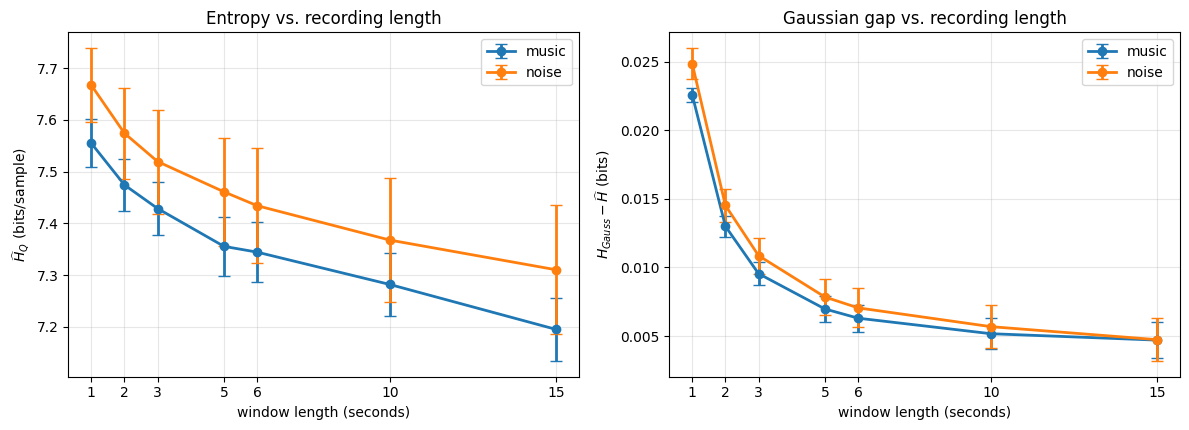

In [49]:
# Plot class means across recording-window lengths.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

for ax, metric, ylabel, title in [
    (axes[0], "H_Q", r"$\widehat H_Q$ (bits/sample)", "Entropy vs. recording length"),
    (axes[1], "gap", r"$H_{Gauss} - \widehat H$ (bits)", "Gaussian gap vs. recording length"),
]:
    for cls in ["music", "noise"]:
        g = (
            length_clip_df[length_clip_df["class"] == cls]
            .groupby("length_s")[metric]
            .agg(["mean", "std", "count"])
        )
        sem = g["std"] / np.sqrt(g["count"])
        ax.errorbar(g.index, g["mean"], yerr=sem, marker="o", capsize=4, linewidth=2, label=cls)
    ax.set_xticks(WINDOW_SECONDS)
    ax.set_xlabel("window length (seconds)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()
